# Lab 5: Regresión Multivariada

**Objetivo:** encontrar los parámetros Θ = (θ₀, θ₁, θ₂) que minimizan el error entre el plano predicho y los datos generados, usando gradiente descendente vectorizado.

El modelo es:

$$h = \Theta^T X$$

La función de coste:

$$J = \frac{1}{2m} \sum_{i=1}^{m} (h^{(i)} - \hat{y}^{(i)})^2$$

El gradiente descendente vectorizado:

$$\nabla J = \Lambda \cdot X^T \qquad \Theta := \Theta - \alpha \nabla J$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.random.seed(42)  # reproducibilidad
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


---
## Punto 1 — Generar datos del plano y = 2.1·x₁ − 3.1·x₂ y gráfico 3D

Se generan N=100 puntos aleatorios en el intervalo [-1, 1] para x₁ y x₂.
Los valores de y se calculan exactamente sobre el plano (sin ruido).
El objetivo al final será recuperar θ₀=0, θ₁=2.1, θ₂=-3.1.

In [2]:
# ── Parámetros reales del plano (los que queremos recuperar) ──────────
THETA0_REAL = 0.0
THETA1_REAL = 2.1
THETA2_REAL = -3.1

N = 100  # número de muestras

# Generar puntos aleatorios en [-1, 1]
x_1 = 2 * np.random.random(N) - 1   # shape (100,)
x_2 = 2 * np.random.random(N) - 1   # shape (100,)

# Calcular y exactamente sobre el plano
y_label = THETA1_REAL * x_1 + THETA2_REAL * x_2   # shape (100,)

print('x_1 shape :', x_1.shape)
print('x_2 shape :', x_2.shape)
print('y_label shape:', y_label.shape)
print(f'y_label min={y_label.min():.3f}  max={y_label.max():.3f}')

x_1 shape : (100,)
x_2 shape : (100,)
y_label shape: (100,)
y_label min=-4.455  max=4.074


In [3]:
# ── Gráfico 3D: superficie del plano + puntos aleatorios ──────────────
# Malla para la superficie
x1_grid = np.linspace(-1, 1, 50)
x2_grid = np.linspace(-1, 1, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
Y_surface = THETA1_REAL * X1_mesh + THETA2_REAL * X2_mesh

fig = go.Figure()

# Superficie del plano
fig.add_trace(go.Surface(
    x=X1_mesh, y=X2_mesh, z=Y_surface,
    opacity=0.6,
    colorscale='Blues',
    name='Plano real'
))

# Puntos de entrenamiento
fig.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers',
    marker=dict(size=4, color='red', opacity=0.8),
    name='Datos generados'
))

fig.update_layout(
    title='Plano y = 2.1·x₁ − 3.1·x₂ con puntos aleatorios',
    scene=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='y'),
    width=750, height=550
)
fig.show()

---
## Punto 2 — Inicializar Θ aleatoriamente

Θ tiene forma **(n+1, 1)** donde n=2 características → Θ es de forma **(3, 1)**.
Las tres componentes son: θ₀ (intercepto), θ₁ (coef. x₁), θ₂ (coef. x₂).

In [4]:
# n+1 = 3 parámetros: theta0, theta1, theta2
Nfeatures = 3   # = n + 1 (incluye el término independiente)

# Inicializar aleatoriamente con forma (3, 1)
theta = np.random.random(Nfeatures).reshape(Nfeatures, 1)

print('Theta inicial (aleatorio):')
print(f'  theta0 = {theta[0, 0]:.4f}  (esperado: {THETA0_REAL})')
print(f'  theta1 = {theta[1, 0]:.4f}  (esperado: {THETA1_REAL})')
print(f'  theta2 = {theta[2, 0]:.4f}  (esperado: {THETA2_REAL})')
print('Shape de theta:', theta.shape)

Theta inicial (aleatorio):
  theta0 = 0.6420  (esperado: 0.0)
  theta1 = 0.0841  (esperado: 2.1)
  theta2 = 0.1616  (esperado: -3.1)
Shape de theta: (3, 1)


---
## Punto 3 — Construir la matriz X de dimensiones (n+1, m)

La primera fila es todo unos (para el término independiente θ₀).
Las filas siguientes son los vectores de características x₁ y x₂.

$$X = \begin{bmatrix} 1 & 1 & \cdots & 1 \\ x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(m)} \\ x_2^{(1)} & x_2^{(2)} & \cdots & x_2^{(m)} \end{bmatrix}_{3 \times 100}$$

In [5]:
# Construir DataFrame con columna de unos
df = pd.DataFrame({'x1': x_1, 'x2': x_2, 'y': y_label})
df['ones'] = 1

# X: dimensión (n+1, m) = (3, 100)
# IMPORTANTE: la primera columna debe ser 'ones'
X = df[['ones', 'x1', 'x2']].values.T    # .T transpone de (100,3) a (3,100)

# Y: dimensión (1, m) = (1, 100)
Y = df['y'].values.reshape(1, N)

m = X.shape[1]          # número de muestras
Nfeatures = X.shape[0]  # n+1 = 3

print('Shape de X:', X.shape, ' <- debe ser (3, 100)')
print('Shape de Y:', Y.shape, ' <- debe ser (1, 100)')
print(f'Nfeatures = {Nfeatures}  |  m = {m}')
print('\nPrimeras 3 columnas de X:')
print(X[:, :3])

Shape de X: (3, 100)  <- debe ser (3, 100)
Shape de Y: (1, 100)  <- debe ser (1, 100)
Nfeatures = 3  |  m = 100

Primeras 3 columnas de X:
[[ 1.          1.          1.        ]
 [-0.25091976  0.90142861  0.46398788]
 [-0.93714163  0.27282082 -0.37128804]]


---
## Punto 4 — Definir las funciones: modelo, costo y gradiente

Siguiendo las dimensiones del lab:

- `h = ΘᵀX`  →  shape **(1, m)**
- `Λ = h − Y`  →  shape **(1, m)**
- `Λ* = (h − Y)²`  →  shape **(1, m)**
- `J = (1/2m) · sum(Λ*)`  →  escalar
- `∇J = Λ · Xᵀ`  →  shape **(1, n+1)** → se transpone a **(n+1, 1)**

In [6]:
def model(theta, X):
    """
    Calcula la prediccion h = Theta^T @ X.
    theta : (n+1, 1)
    X     : (n+1, m)
    retorna h de shape (1, m)
    """
    return theta.T @ X      # (1, n+1) @ (n+1, m) = (1, m)


def costo(h, Y, m):
    """
    Funcion de coste cuadratica J = (1/2m) * sum((h - Y)^2).
    h : (1, m)
    Y : (1, m)
    retorna J escalar
    """
    Lambda_star = (h - Y) ** 2          # (1, m) — error cuadratico por muestra
    J = (1 / (2 * m)) * np.sum(Lambda_star)
    return J


def update_params(theta, h, Y, X, m, learning_rate):
    """
    Gradiente descendente vectorizado.
    nabla_J = (1/m) * Lambda @ X^T   shape: (1, n+1) -> transponer a (n+1, 1)
    theta_nuevo = theta - alpha * nabla_J
    """
    Lambda    = (h - Y)                          # (1, m)
    grad      = (1 / m) * np.dot(Lambda, X.T).T  # (n+1, 1)
    theta_new = theta - learning_rate * grad
    return theta_new


# Prueba rapida de dimensiones
h_test = model(theta, X)
J_test = costo(h_test, Y, m)
print('Prueba de dimensiones:')
print(f'  h shape   : {h_test.shape}   <- debe ser (1, 100)')
print(f'  J inicial : {J_test:.6f}   (valor alto, theta es aleatorio)')

Prueba de dimensiones:
  h shape   : (1, 100)   <- debe ser (1, 100)
  J inicial : 2.878850   (valor alto, theta es aleatorio)


---
## Punto 5 y 6 — Iterar el gradiente descendente hasta converger

Se itera Niter veces actualizando Θ en cada paso.
Al final, θ₁ debe acercarse a 2.1 y θ₂ a -3.1.

In [7]:
# ── Hiperparámetros ────────────────────────────────────────────────────
learning_rate = 0.01
Niter         = 1000

# ── Reinicializar theta ────────────────────────────────────────────────
np.random.seed(42)
theta = np.random.random(Nfeatures).reshape(Nfeatures, 1)

# ── Guardar historial de costos ────────────────────────────────────────
J_hist = np.zeros(Niter)

# ── Bucle de entrenamiento ─────────────────────────────────────────────
for i in range(Niter):
    h          = model(theta, X)                          # prediccion
    J_hist[i]  = costo(h, Y, m)                           # costo actual
    theta      = update_params(theta, h, Y, X, m, learning_rate)  # actualizar

# ── Resultados ─────────────────────────────────────────────────────────
print('=== Resultados tras el entrenamiento ===')
print(f'  theta0 = {theta[0, 0]:.6f}  (esperado: {THETA0_REAL})')
print(f'  theta1 = {theta[1, 0]:.6f}  (esperado: {THETA1_REAL})')
print(f'  theta2 = {theta[2, 0]:.6f}  (esperado: {THETA2_REAL})')
print(f'  J final = {J_hist[-1]:.8f}')

=== Resultados tras el entrenamiento ===
  theta0 = -0.001157  (esperado: 0.0)
  theta1 = 2.080469  (esperado: 2.1)
  theta2 = -2.976390  (esperado: -3.1)
  J final = 0.00271319


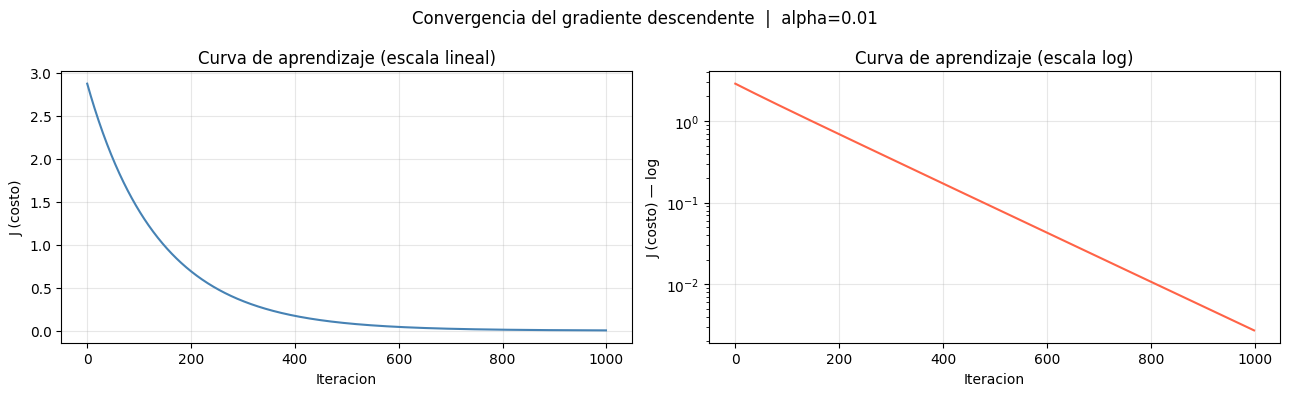

In [8]:
# ── Curva de aprendizaje (J vs iteraciones) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Escala lineal
axes[0].plot(J_hist, color='steelblue', linewidth=1.5)
axes[0].set_title('Curva de aprendizaje (escala lineal)')
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('J (costo)')
axes[0].grid(True, alpha=0.3)

# Escala logaritmica para ver la convergencia
axes[1].semilogy(J_hist, color='tomato', linewidth=1.5)
axes[1].set_title('Curva de aprendizaje (escala log)')
axes[1].set_xlabel('Iteracion')
axes[1].set_ylabel('J (costo) — log')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Convergencia del gradiente descendente  |  alpha={learning_rate}', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# ── Grafico 3D: plano real vs plano ajustado por el modelo ────────────
Y_pred_surface = theta[1, 0] * X1_mesh + theta[2, 0] * X2_mesh + theta[0, 0]

fig = go.Figure()

# Plano real
fig.add_trace(go.Surface(
    x=X1_mesh, y=X2_mesh, z=Y_surface,
    opacity=0.5, colorscale='Blues', name='Plano real',
    showscale=False
))

# Plano ajustado
fig.add_trace(go.Surface(
    x=X1_mesh, y=X2_mesh, z=Y_pred_surface,
    opacity=0.5, colorscale='Reds', name='Plano ajustado',
    showscale=False
))

# Puntos de entrenamiento
fig.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers',
    marker=dict(size=3, color='white'),
    name='Datos'
))

fig.update_layout(
    title=f'Plano real (azul) vs Ajustado (rojo)<br>theta0={theta[0,0]:.4f}  theta1={theta[1,0]:.4f}  theta2={theta[2,0]:.4f}',
    scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='y'),
    width=750, height=550
)
fig.show()

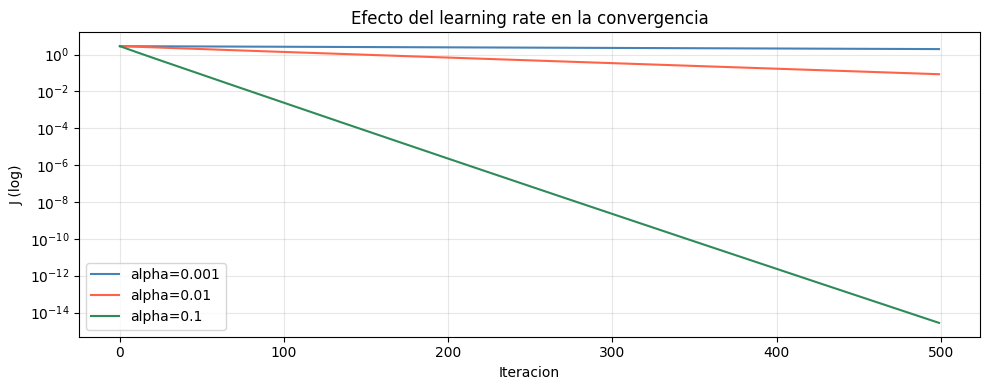

In [10]:
# ── Efecto del learning_rate: comparar 3 valores ──────────────────────
alphas   = [0.001, 0.01, 0.1]
colores  = ['steelblue', 'tomato', 'seagreen']
Niter_lr = 500

plt.figure(figsize=(10, 4))
for alpha, color in zip(alphas, colores):
    np.random.seed(42)
    th = np.random.random(Nfeatures).reshape(Nfeatures, 1)
    J_lr = np.zeros(Niter_lr)
    for i in range(Niter_lr):
        h_lr    = model(th, X)
        J_lr[i] = costo(h_lr, Y, m)
        th      = update_params(th, h_lr, Y, X, m, alpha)
    plt.semilogy(J_lr, color=color, label=f'alpha={alpha}')

plt.xlabel('Iteracion')
plt.ylabel('J (log)')
plt.title('Efecto del learning rate en la convergencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Punto 7 — Reescribir el código como clase `MultilinearRegresion`

Se completan los `...` del esqueleto provisto en el lab.
La clase encapsula: datos, modelo, costo, actualización de parámetros y bucle de entrenamiento.

In [11]:
class MultilinearRegresion:
    """
    Regresion lineal multivariada entrenada con gradiente descendente vectorizado.

    Parametros
    ----------
    X : ndarray de shape (n+1, m)
        Matriz de diseno (primera fila = unos).
    Y : ndarray de shape (1, m)
        Vector de etiquetas.
    """

    def __init__(self, X, Y):
        self.X         = X                        # (n+1, m)
        self.Y         = Y                        # (1, m)
        Nfeatures      = X.shape[0]               # n+1
        self.m         = X.shape[1]               # numero de muestras
        self.theta     = np.random.random(Nfeatures).reshape(Nfeatures, 1)
        self.J_hist    = []                       # historial de costos

    def model(self):
        """
        Prediccion: h = Theta^T @ X
        h tiene shape (1, m)
        """
        self.h = self.theta.T @ self.X            # (1, n+1) @ (n+1, m) = (1, m)

    def costo(self):
        """
        Funcion de coste: J = (1/2m) * sum((h - Y)^2)
        """
        Lambda_star = (self.h - self.Y) ** 2
        self.J      = (1 / (2 * self.m)) * np.sum(Lambda_star)
        self.J_hist.append(self.J)

    def update_params(self, learning_rate):
        """
        Gradiente descendente vectorizado.
        nabla_J = (1/m) * Lambda @ X^T  -> shape (n+1, 1)
        Theta := Theta - alpha * nabla_J
        """
        Lambda      = (self.h - self.Y)                              # (1, m)
        grad        = (1 / self.m) * np.dot(Lambda, self.X.T).T     # (n+1, 1)
        self.theta  = self.theta - learning_rate * grad

    def fit(self, learning_rate=0.01, Niter=1000):
        """
        Bucle de entrenamiento: Niter iteraciones de gradiente descendente.
        """
        for i in range(Niter):
            self.model()
            self.costo()
            self.update_params(learning_rate)

    def predict(self, X_new):
        """
        Prediccion sobre nuevos datos.
        X_new : (n+1, k) — ya debe incluir la fila de unos
        """
        return self.theta.T @ X_new

    def summary(self):
        """Imprime los parametros encontrados."""
        print('=== MultilinearRegresion — parametros encontrados ===')
        for j, val in enumerate(self.theta.flatten()):
            print(f'  theta{j} = {val:.6f}')
        print(f'  J final = {self.J:.8f}')


print('Clase MultilinearRegresion definida correctamente')

Clase MultilinearRegresion definida correctamente


In [12]:
# ── Entrenar usando la clase ───────────────────────────────────────────
np.random.seed(42)
modelo = MultilinearRegresion(X, Y)
modelo.fit(learning_rate=0.01, Niter=1000)
modelo.summary()

print(f'\nValores esperados: theta0={THETA0_REAL}  theta1={THETA1_REAL}  theta2={THETA2_REAL}')

=== MultilinearRegresion — parametros encontrados ===
  theta0 = -0.001157
  theta1 = 2.080469
  theta2 = -2.976390
  J final = 0.00271319

Valores esperados: theta0=0.0  theta1=2.1  theta2=-3.1


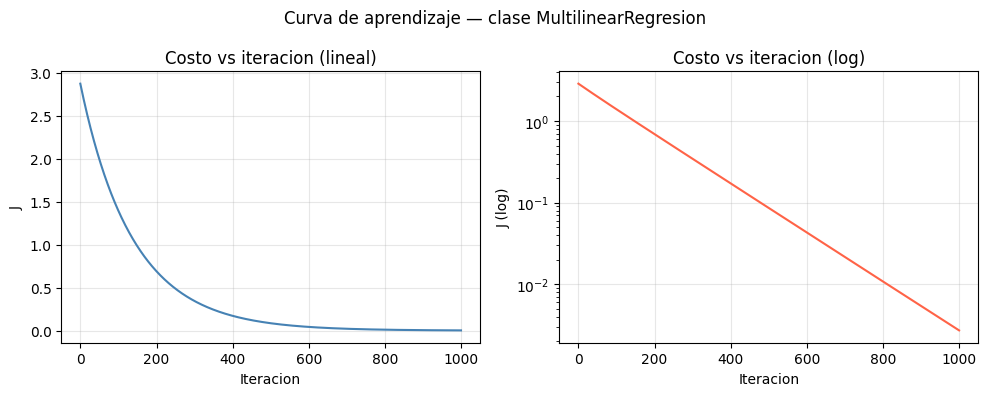

In [13]:
# ── Curva de aprendizaje con la clase ─────────────────────────────────
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(modelo.J_hist, color='steelblue', linewidth=1.5)
plt.xlabel('Iteracion')
plt.ylabel('J')
plt.title('Costo vs iteracion (lineal)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(modelo.J_hist, color='tomato', linewidth=1.5)
plt.xlabel('Iteracion')
plt.ylabel('J (log)')
plt.title('Costo vs iteracion (log)')
plt.grid(True, alpha=0.3)

plt.suptitle('Curva de aprendizaje — clase MultilinearRegresion', fontsize=12)
plt.tight_layout()
plt.show()

---
## Verificacion final — comparar con sklearn

Se verifica que los parametros obtenidos coinciden con los de `LinearRegression` de sklearn.

In [14]:
from sklearn.linear_model import LinearRegression

# sklearn espera X de shape (m, n) — sin la columna de unos
X_sk = np.column_stack([x_1, x_2])   # (100, 2)
y_sk = y_label                        # (100,)

lr_sk = LinearRegression(fit_intercept=True)
lr_sk.fit(X_sk, y_sk)

print('=== Comparacion de parametros ===')
print(f'  theta0  —  Clase: {modelo.theta[0,0]:.6f}  |  sklearn: {lr_sk.intercept_:.6f}  |  Real: {THETA0_REAL}')
print(f'  theta1  —  Clase: {modelo.theta[1,0]:.6f}  |  sklearn: {lr_sk.coef_[0]:.6f}   |  Real: {THETA1_REAL}')
print(f'  theta2  —  Clase: {modelo.theta[2,0]:.6f}  |  sklearn: {lr_sk.coef_[1]:.6f}  |  Real: {THETA2_REAL}')

=== Comparacion de parametros ===
  theta0  —  Clase: -0.001157  |  sklearn: -0.000000  |  Real: 0.0
  theta1  —  Clase: 2.080469  |  sklearn: 2.100000   |  Real: 2.1
  theta2  —  Clase: -2.976390  |  sklearn: -3.100000  |  Real: -3.1


---
## Prueba adicional — dataset con ruido

Se repite el experimento agregando ruido gaussiano a y. El modelo debe encontrar parametros cercanos a los reales a pesar del ruido.

In [15]:
# Agregar ruido al plano
np.random.seed(0)
ruido    = 0.3 * (2 * np.random.random(N) - 1)
y_noisy  = THETA1_REAL * x_1 + THETA2_REAL * x_2 + ruido

# Construir X e Y con ruido
df_noisy    = pd.DataFrame({'x1': x_1, 'x2': x_2, 'y': y_noisy})
df_noisy['ones'] = 1
X_noisy     = df_noisy[['ones', 'x1', 'x2']].values.T
Y_noisy     = df_noisy['y'].values.reshape(1, N)

# Entrenar
np.random.seed(42)
modelo_noisy = MultilinearRegresion(X_noisy, Y_noisy)
modelo_noisy.fit(learning_rate=0.01, Niter=2000)

print('=== Resultado con ruido ===')
modelo_noisy.summary()
print(f'\nValores esperados: theta0={THETA0_REAL}  theta1={THETA1_REAL}  theta2={THETA2_REAL}')

=== Resultado con ruido ===
=== MultilinearRegresion — parametros encontrados ===
  theta0 = -0.016893
  theta1 = 2.091592
  theta2 = -3.115431
  J final = 0.01488922

Valores esperados: theta0=0.0  theta1=2.1  theta2=-3.1
